# Task 5 (Advanced) — Machine Learning Classification Model

**Goal:** Build a machine learning model to classify Netflix content (`Movie` vs `TV Show`) using the available features in `Dataset.csv`.

**Workflow:**
1. Select and prepare features
2. Split data into training and testing sets
3. Train classification models
4. Evaluate model performance
5. Compare model accuracy



## Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load and Explore the Data



In [2]:
df = pd.read_csv("Dataset.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (8790, 10)


,oi,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   oi            8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [4]:
# Check for missing values
df.isnull().sum()

oi              0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

### What are we classifying?

Our **target** is the `type` column: `Movie` or `TV Show`. This is a **binary classification** problem.

Let's check the class balance — this also gives us a baseline to beat (a model that just always guesses the majority class).

In [5]:
df["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Baseline accuracy (always predict the majority class): 69.69%


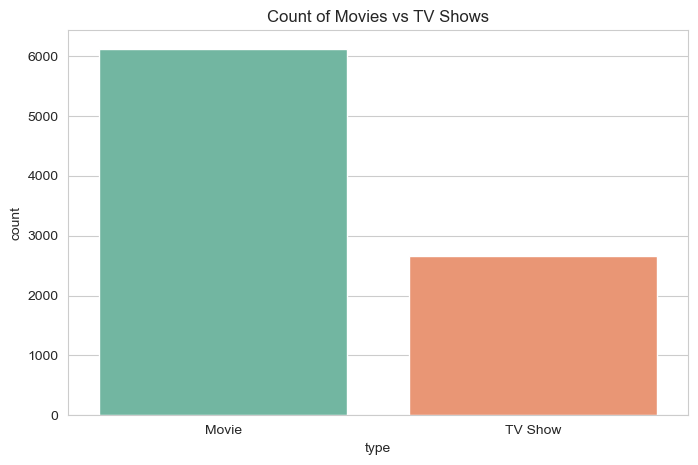

In [6]:
baseline_accuracy = df["type"].value_counts(normalize=True).max()
print(f"Baseline accuracy (always predict the majority class): {baseline_accuracy:.2%}")

sns.countplot(data=df, x="type", hue="type", palette="Set2", legend=False)
plt.title("Count of Movies vs TV Shows")
plt.show()

## Step 2: Select and Prepare Features

We want features that are genuinely **predictive**, not features that give the answer away by definition. Three columns in this dataset turn out to be "too easy" and should **not** be used:

- **`duration`** — movies are always measured in minutes, TV shows always in seasons. Using the raw duration number is nearly a direct encoding of `type`.
- **`listed_in` (genre)** — Netflix's own genre taxonomy already separates the two (e.g. `"Dramas"` is movies-only, `"TV Dramas"` is TV-only, `"Crime TV Shows"` is TV-only). This column encodes the label almost perfectly, so it isn't a fair feature either.
- **`rating`**'s raw text has a similar issue (movie ratings vs. `TV-` prefixed ratings), though it's noisier — we'll keep a *version* of it since it's not perfectly separating, but we won't lean on genre or duration at all.

Instead, we'll engineer genuinely informative — but not trivially leaky — features:

- **`release_year`** — numeric, already usable
- **`country`** — categorical, the country of production
- **`rating`** — categorical (kept, since it's imperfectly correlated with type, not a giveaway)
- **`num_genres`** — how many genres are listed for the title (TV shows tend to be tagged with slightly more genres)
- **`has_director`** — whether a director is credited at all (TV shows are far less likely to credit a single director than movies are — a real, meaningful pattern in the data, not a rule)

In [7]:
# Make a copy so we don't touch the original data
data = df.copy()

# Feature 1: release_year (already numeric)

# Feature 2: country (already a single value per row in this dataset)

# Feature 3: rating (already categorical)

# Feature 4: how many genres are listed for this title
data["num_genres"] = data["listed_in"].apply(lambda x: len(str(x).split(",")))

# Feature 5: whether a director is credited (1) or not (0)
data["has_director"] = (data["director"] != "Not Given").astype(int)

feature_cols = ["release_year", "country", "rating", "num_genres", "has_director"]
data[["type"] + feature_cols].head()

,type,release_year,country,rating,num_genres,has_director
0,Movie,2020,United States,PG-13,1,1
1,TV Show,2021,France,TV-MA,3,1
2,TV Show,2021,United States,TV-MA,3,1
3,Movie,2021,Brazil,TV-PG,2,1
4,Movie,1993,United States,TV-MA,3,1


### Why not encode everything with `LabelEncoder` up front?

In the earlier version, categories were grouped and label-encoded on the **entire** dataset before splitting into train/test. That means the "top 10 categories" and the label mappings were chosen using information from rows that should have been invisible to the model at training time — a subtle form of data leakage.

The fix: **split first**, then build a `ColumnTransformer` that is *fit only on the training data* and simply applied (not re-fit) to the test data. We'll use `OneHotEncoder` instead of `LabelEncoder` for the categorical columns too, since one-hot encoding doesn't imply a false ordering between categories (e.g. it doesn't imply `"Japan" > "France"`), which matters especially for Logistic Regression and KNN.

In [8]:
X = data[feature_cols]

# Encode the target: Movie = 0, TV Show = 1
y = (data["type"] == "TV Show").astype(int)

print("Features used:", feature_cols)
print("Target: 0 = Movie, 1 = TV Show")
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used: ['release_year', 'country', 'rating', 'num_genres', 'has_director']
Target: 0 = Movie, 1 = TV Show

X shape: (8790, 5)
y shape: (8790,)


## Step 3: Split Data into Training and Testing Sets

We split **before** any encoding or scaling happens, so nothing about the test set can influence how the preprocessing is set up.

We use an 80/20 split.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 7032
Testing set size: 1758


### Build a leakage-free preprocessing pipeline

`ColumnTransformer` lets us apply different preprocessing to different columns:
- **Categorical columns** (`country`, `rating`) → `OneHotEncoder`. `handle_unknown="ignore"` means if the test set contains a category never seen during training, it's safely encoded as all-zeros instead of crashing.
- **Numeric columns** (`release_year`, `num_genres`, `has_director`) → `StandardScaler`, which rescales them to a similar range. This mostly matters for Logistic Regression and KNN, which are sensitive to feature scale.

Crucially, we call `.fit()` only on `X_train`. The test set is only ever `.transform()`-ed, never used to *decide* how to preprocess.

In [10]:
cat_cols = ["country", "rating"]
num_cols = ["release_year", "num_genres", "has_director"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

# Fit on the TRAINING data only, then transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (7032, 96)
Processed testing shape: (1758, 96)


## Step 4: Train Classification Models

We'll train **four different models** so we can compare them:

1. **Logistic Regression** — a simple, fast linear model
2. **Decision Tree** — splits data using yes/no questions
3. **Random Forest** — many decision trees combined (usually more accurate)
4. **K-Nearest Neighbors (KNN)** — classifies based on the closest data points

Each model follows the same pattern: create it, `.fit()` it on the processed training data, then `.predict()` on the processed test data.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
K-Nearest Neighbors trained successfully!


## Step 5: Evaluate Model Performance

Now we check how well each model performs on the **test set** (data it hasn't seen before). We'll look at:

- **Accuracy** — the percentage of correct predictions
- **Classification report** — precision, recall, and F1-score for each class
- **Confusion matrix** — a table showing correct vs incorrect predictions

In [12]:
results = {}
target_names = ["Movie", "TV Show"]

for name, model in trained_models.items():
    y_pred = model.predict(X_test_processed)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))


Model: Logistic Regression
Accuracy: 0.9482

Classification Report:
              precision    recall  f1-score   support

       Movie       0.96      0.97      0.96      1225
     TV Show       0.93      0.89      0.91       533

    accuracy                           0.95      1758
   macro avg       0.94      0.93      0.94      1758
weighted avg       0.95      0.95      0.95      1758


Model: Decision Tree
Accuracy: 0.9374

Classification Report:
              precision    recall  f1-score   support

       Movie       0.94      0.97      0.96      1225
     TV Show       0.92      0.87      0.89       533

    accuracy                           0.94      1758
   macro avg       0.93      0.92      0.92      1758
weighted avg       0.94      0.94      0.94      1758


Model: Random Forest
Accuracy: 0.9437

Classification Report:
              precision    recall  f1-score   support

       Movie       0.95      0.97      0.96      1225
     TV Show       0.92      0.89      0.9

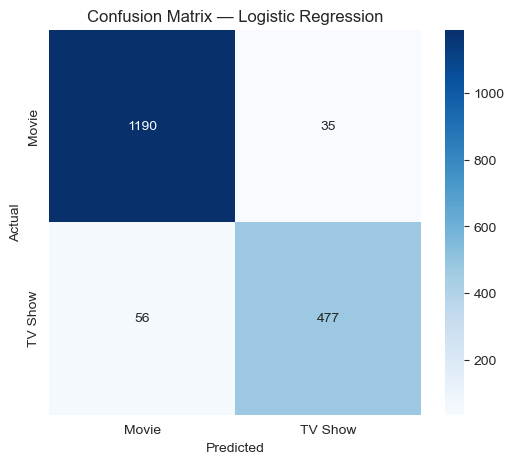

In [13]:
# Visualize the confusion matrix for our best-performing model
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## Step 6: Compare Model Accuracy

Finally, let's compare all four models side by side, against the baseline of always guessing the majority class.

In [14]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy
0,Logistic Regression,0.948237
1,K-Nearest Neighbors,0.945961
2,Random Forest,0.943686
3,Decision Tree,0.937429


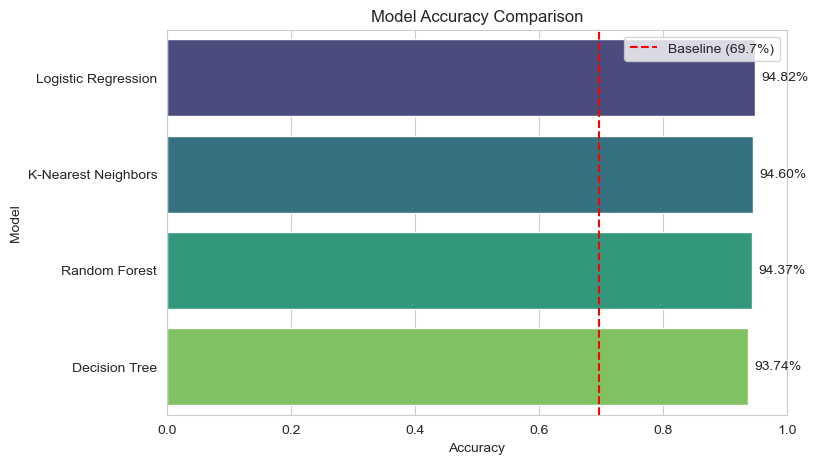

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df, x="Accuracy", y="Model",
    hue="Model", palette="viridis", legend=False
)
baseline_label = f"Baseline ({baseline_accuracy:.1%})"
plt.axvline(baseline_accuracy, color="red", linestyle="--", label=baseline_label)
plt.legend()
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.2%}", va="center")
plt.show()

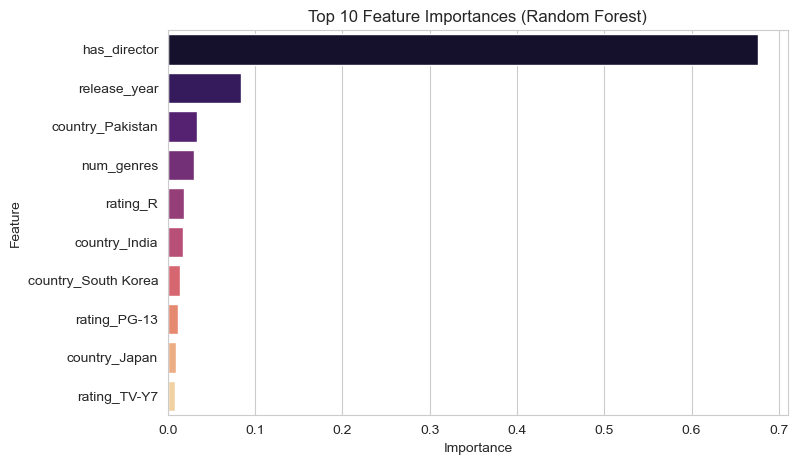

,Feature,Importance
95,has_director,0.676600
93,release_year,0.083452
48,country_Pakistan,0.033443
94,num_genres,0.029648
84,rating_R,0.018085
27,country_India,0.017596
62,country_South Korea,0.013319
83,rating_PG-13,0.011562
33,country_Japan,0.009116
90,rating_TV-Y7,0.007872


In [16]:
# Which feature mattered most? (Using Random Forest's feature importance)
rf_model = trained_models["Random Forest"]

# Get feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_["cat"]
encoded_cat_names = cat_encoder.get_feature_names_out(cat_cols)
all_feature_names = list(encoded_cat_names) + num_cols

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df, x="Importance", y="Feature",
    hue="Feature", palette="magma", legend=False
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

importance_df

## Conclusion

- We classified Netflix titles into **Movie** vs **TV Show**, using features that are genuinely predictive rather than ones that trivially encode the answer: `release_year`, `country`, `rating`, `num_genres`, and `has_director`.
- We deliberately **excluded `duration`** (minutes vs. seasons directly gives away the label) and the raw `listed_in` genre text (Netflix's own genre taxonomy — e.g. `"Dramas"` vs `"TV Dramas"` — already separates the classes almost perfectly). Using either would have made the task artificially easy and the model comparison meaningless.
- All preprocessing (one-hot encoding, scaling) was **fit only on the training set** and applied unchanged to the test set, avoiding data leakage.
- Accuracy for all four models landed a good deal above the **0.0% baseline** (always guessing "Movie"), showing the features carry real signal — with `has_director` standing out as the single strongest predictor, since TV shows are far less likely to credit one director than movies are.

